# Olist Brazilian E-Commerce — End-to-End Data Analysis

---

## 📋 Project Overview

| | |
|---|---|
| **Dataset** | [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) |
| **Source** | Kaggle / Olist (real anonymised transactions) |
| **Scope** | ~100,000 orders placed on Olist marketplace between 2016 – 2018 |
| **Tables used** | customers, geolocation, order_items, order_payments, order_reviews, orders, products, sellers, category_translation |
| **Tech stack** | Python 3 · Pandas · SciPy · Matplotlib · Seaborn · SQLAlchemy · MySQL |
| **Author** | Akanksha Jha |

---

## 📝 Executive Summary

This notebook performs a **full analytics pipeline** on Brazil's largest public e-commerce dataset.  
Starting from nine raw CSV files, the project:

1. **Loads and audits** all nine source tables, verifying shape, types, and null counts.  
2. **Cleans each table individually** — fixing data types, standardising text casing, removing invalid records, engineering derived columns, and resolving duplicates.  
3. **Aggregates** multi-row tables (payments, reviews) to order-level granularity before joining.  
4. **Builds a single unified master DataFrame** by progressively merging all tables via shared keys (order_id, customer_id, product_id, seller_id, zip prefix).  
5. **Exports** the master table to a MySQL database via SQLAlchemy for downstream SQL querying.  
6. **Conducts a statistical hypothesis test** (independent samples t-test) to determine whether late deliveries are significantly associated with lower customer review scores — a key business question for any marketplace operations team.

**Key finding:** Late deliveries are statistically associated with significantly lower review scores (p ≈ 0), confirming that delivery performance is a critical driver of customer satisfaction on the Olist platform.

---

## 🗂️ Notebook Structure

| Section | Description |
|---|---|
| 1. Environment Setup | Working directory & library imports |
| 2. Data Loading | Reading all 9 CSVs into DataFrames |
| 3. Data Cleaning — Customers | Deduplication, casing, rename |
| 4. Data Cleaning — Geolocation | Aggregation to zip-level, rename |
| 5. Data Cleaning — Order Items | Type conversion, feature engineering |
| 6. Data Cleaning — Order Payments | Invalid record removal, installments fix, aggregation |
| 7. Data Cleaning — Order Reviews | Null handling, datetime parsing, response time feature |
| 8. Data Cleaning — Orders | Datetime conversion, delivery KPI engineering |
| 9. Data Cleaning — Category Translation | Standardisation |
| 10. Data Cleaning — Products | Null imputation, merge with translations |
| 11. Data Cleaning — Sellers | Casing & rename |
| 12. Master DataFrame Assembly | Progressive left-joins across all tables |
| 13. Export to MySQL | SQLAlchemy engine & `to_sql` |
| 14. Hypothesis Testing | A/B-style t-test: delivery delay vs. review score |


---
## 1. Environment Setup

### 1.1 Working Directory

**What:** Sets the Python working directory to the local folder that contains all nine Olist CSV files.  
**Why:** All subsequent `pd.read_csv()` calls use relative filenames, so the working directory must point to the folder where the data lives. On a shared or cloud environment this cell would be replaced with an absolute path or a cloud storage URI.


In [1]:
%cd "C:\\Users\\Akanksha Jha\\OneDrive\\Desktop\\sql"


C:\Users\Akanksha Jha\OneDrive\Desktop\sql


### 1.2 Library Imports

**What:** Imports `pandas`, the primary data manipulation library used throughout this project.  
**Why:** Additional libraries (matplotlib, seaborn, scipy, sqlalchemy) are imported later, at the point of first use, following a convention that keeps early cells lightweight and makes dependency errors easier to locate.


In [2]:
import pandas as pd

---
## 2. Data Loading

### 2.1 Load All Source Tables

**What:** Reads all nine Olist CSV files into separate pandas DataFrames in a single cell.  
**Why:** Keeping every read statement together gives an immediate, scannable inventory of the data sources. The nine tables represent a normalised relational schema:

| DataFrame | Description |
|---|---|
| `customers` | Customer identity & location (zip, city, state) |
| `geolocation` | Latitude/longitude lookup by zip code prefix |
| `order_items` | Line items — product, seller, price, freight per order |
| `order_payments` | Payment method, value, and instalment plan |
| `order_reviews` | Customer ratings and free-text comments |
| `order` | Order lifecycle timestamps & status |
| `product` | Product catalogue with dimensions and weight |
| `seller` | Seller identity & location |
| `category_translation` | Portuguese → English product category mapping |

A left-join strategy (detailed in Section 12) will stitch these tables into one analytical master DataFrame.


In [3]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
order = pd.read_csv("olist_orders_dataset.csv")
product = pd.read_csv("olist_products_dataset.csv")
seller = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

---
## 3. Data Cleaning — Customers Table

### 3.1 Initial Inspection

**What:** Previews the category_translation table, checks for nulls, and inspects the order_payments schema.  
**Why:** These are quick sanity checks run immediately after loading to catch obvious problems (e.g., all-null columns, unexpected dtypes) before investing time in deeper cleaning.


In [4]:
category_translation.head()


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [5]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [6]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


### 3.2 Customers — Audit & Deduplication

**What:** Inspects the customers DataFrame structure and checks for duplicate `customer_id` values.  
**Why:** Duplicate customer IDs would corrupt downstream joins by introducing extra rows. This check confirms whether deduplication is required before any merges.


In [7]:
print(customers.info)

<bound method DataFrame.info of                             customer_id                customer_unique_id  \
0      06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1      18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2      4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3      b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4      4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                 ...                               ...   
99436  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
99437  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
99438  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
99439  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
99440  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

       customer_zip_code_prefix          cu

In [8]:
print(f"Duplicate customer_ids: {customers["customer_id"].duplicated().sum()}")

Duplicate customer_ids: 0


### 3.3 Customers — Text Standardisation

**What:** Lowercases and strips whitespace from `customer_city`; drops full-row duplicates; resets the index.  
**Why:** Text fields sourced from user input or legacy systems often have inconsistent casing ("São Paulo" vs "são paulo") or trailing spaces. Standardising to lowercase-stripped ensures that city-level groupBys and joins behave correctly. `drop_duplicates()` removes any identical rows introduced by system logging, and `reset_index(drop=True)` gives a clean 0-based integer index.


In [9]:
customers["customer_city"] = customers["customer_city"].str.lower()

In [10]:
customers["customer_city"] = customers["customer_city"].str.strip()

In [11]:
customers = customers.drop_duplicates().reset_index(drop = True)


In [12]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### 3.4 Customers — State Standardisation & Column Rename

**What:** Uppercases and strips `customer_state`; renames `customer_zip_code_prefix` to `zip_prefix`.  
**Why:** Brazilian state abbreviations (e.g., "SP", "RJ") are standardised to UPPER to match the join key in the geolocation table. The column rename shortens the key to `zip_prefix` — a shared name used across customers, geolocation, and eventually the master DataFrame to enable consistent merging.


In [13]:
customers["customer_state"] = customers["customer_state"].str.upper()
customers["customer_state"] = customers["customer_state"].str.strip()

In [14]:
customers.rename(columns={"customer_zip_code_prefix":"zip_prefix"},inplace =True)

In [15]:
customers["customer_state"].value_counts().head()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

In [16]:
customers.tail()


,customer_id,customer_unique_id,zip_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP


In [17]:
customers.isnull().sum()

customer_id           0
customer_unique_id    0
zip_prefix            0
customer_city         0
customer_state        0
dtype: int64

In [18]:
len(customers)

99441

In [19]:
customers["customer_id"].nunique()

99441

---
## 4. Data Cleaning — Geolocation Table

### 4.1 Geolocation — Audit

**What:** Checks nulls, previews rows, inspects shape and data types, and counts duplicates in the raw geolocation table.  
**Why:** The raw geolocation file contains ~1 million rows because each zip code prefix appears multiple times with slightly different coordinates (one row per postal delivery point). Understanding this fan-out is essential before using the table as a lookup.


In [20]:
geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [21]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [22]:
geolocation.shape

(1000163, 5)

In [23]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [24]:
geolocation.duplicated().sum()

np.int64(261831)

### 4.2 Geolocation — Aggregate to Zip-Level

**What:** Groups by `geolocation_zip_code_prefix` and aggregates — taking the **mean** latitude/longitude and the **first** city/state per zip prefix — to create a deduplicated `geo` lookup table.  
**Why:** A single zip prefix maps to multiple raw rows. To join geolocation onto the customer table (which only stores a zip prefix, not an exact coordinate), we need exactly one row per prefix. Using **mean** coordinates produces a centroid representative of that zip area. Using **first** for city/state is a practical approximation — Brazilian zip prefix areas are typically within the same city.


In [25]:
geo = geolocation.groupby("geolocation_zip_code_prefix").agg({
      "geolocation_lat":"mean",
      "geolocation_lng":"mean",
      "geolocation_city":"first",
      "geolocation_state":"first"}).reset_index()

In [26]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.550190,-46.634024,sao paulo,SP
1,1002,-23.548146,-46.634979,sao paulo,SP
2,1003,-23.548994,-46.635731,sao paulo,SP
3,1004,-23.549799,-46.634757,sao paulo,SP
4,1005,-23.549456,-46.636733,sao paulo,SP


In [27]:
geo.duplicated().sum()

np.int64(0)

### 4.3 Geolocation — Rename & Final Standardisation

**What:** Renames columns to `zip_prefix`, `latitude`, `longitude`; standardises city/state casing.  
**Why:** Renaming aligns the join key with the customers table (`zip_prefix`) so the merge in Section 12 is unambiguous. Casing standardisation follows the same logic applied to the customers table — consistent lowercase city and uppercase state abbreviations.


In [28]:
geo.rename(columns={"geolocation_zip_code_prefix":"zip_prefix","geolocation_lat":"latitude","geolocation_lng":"longitude"},inplace=True)

In [29]:
geo.head()

,zip_prefix,latitude,longitude,geolocation_city,geolocation_state
0,1001,-23.550190,-46.634024,sao paulo,SP
1,1002,-23.548146,-46.634979,sao paulo,SP
2,1003,-23.548994,-46.635731,sao paulo,SP
3,1004,-23.549799,-46.634757,sao paulo,SP
4,1005,-23.549456,-46.636733,sao paulo,SP


In [30]:
geo["geolocation_city"] = geo["geolocation_city"].str.strip().str.lower()

In [31]:
geo["geolocation_state"] = geo["geolocation_state"].str.strip().str.upper()

In [32]:
geo.head()
geo.shape

(19015, 5)

---
## 5. Data Cleaning — Order Items Table

### 5.1 Order Items — Audit

**What:** Previews, checks shape/info/nulls/duplicates for the order_items table.  
**Why:** Order items represent the commercial core of the dataset — each row is a product sold within an order. Clean data here is critical because `price` and `freight_value` feed directly into revenue and margin calculations.


In [33]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57,199.90,18.14


In [34]:
order_items.shape
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [35]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [36]:
order_items.duplicated().sum()

np.int64(0)

### 5.2 Order Items — Date Parsing & Price Feature Engineering

**What:** Parses `shipping_limit_date` to datetime; creates `total_price` as the sum of `price` and `freight_value`; previews the resulting distributions.  
**Why:**  
- **Date parsing:** `shipping_limit_date` arrives as a string object. Converting to datetime enables time-based filtering and arithmetic.  
- **`total_price`:** From a customer's perspective, the real cost of an order line is the item price *plus* shipping. Creating this derived column encapsulates that business logic in one place, making downstream aggregations (e.g., revenue per order) simpler and less error-prone than repeatedly summing two columns.


In [37]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

In [38]:
order_items[["price","freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [39]:
order_items["total_price"] = order_items["price"] + order_items["freight_value"]

In [40]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:00,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:00,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:00,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:00,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:00,199.90,18.14,218.04


In [41]:
order_items[['price','freight_value','total_price']].describe()

,price,freight_value,total_price
count,112650.000000,112650.000000,112650.000000
mean,120.653739,19.990320,140.644059
std,183.633928,15.806405,190.724394
min,0.850000,0.000000,6.080000
25%,39.900000,13.080000,55.220000
50%,74.990000,16.260000,92.320000
75%,134.900000,21.150000,157.937500
max,6735.000000,409.680000,6929.310000


---
## 6. Data Cleaning — Order Payments Table

### 6.1 Order Payments — Audit

**What:** Inspects schema, previews rows, checks shape, nulls, and duplicates.  
**Why:** The payments table is many-to-one with orders (one order can have multiple payment methods or instalments). Understanding this structure is prerequisite to the aggregation in §6.3.


In [42]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [43]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [44]:
order_payments.shape

(103886, 5)

In [45]:
order_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [46]:
order_payments.duplicated().sum()

np.int64(0)

### 6.2 Order Payments — Type Casting & Invalid Record Removal

**What:** Casts `payment_value` to float and `payment_installments` to int; removes rows where `payment_type` is `"not_defined"`; removes rows where `payment_value ≤ 0`; fixes zero-instalment records.  
**Why:**  
- **Type casting:** Ensures arithmetic operations on payment columns behave correctly (e.g., no silent string concatenation instead of addition).  
- **`"not_defined"` removal:** These entries carry no meaningful business information and would skew payment-type distributions.  
- **Zero/negative values:** Payments ≤ 0 are data errors — refunds, voids, or system artefacts — that would corrupt revenue totals.  
- **Zero instalments → 1:** An instalment count of 0 is logically invalid. A minimum of 1 (full upfront payment) is substituted to preserve the record without distorting the instalment distribution.


In [47]:
order_payments["payment_value"] = order_payments["payment_value"].astype(float)
order_payments["payment_installments"] = order_payments["payment_installments"].astype(int)

In [48]:
order_payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [49]:
order_payments = order_payments[order_payments["payment_type"] !="not_defined"]

In [50]:
invalid_payments = order_payments[order_payments["payment_value"] <= 0]
invalid_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0


In [51]:
order_payments = order_payments[order_payments["payment_value"] >0]

In [52]:
order_payments["payment_installments"].describe()

count    103877.000000
mean          2.853509
std           2.687112
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [53]:
order_payments.loc[order_payments["payment_installments"]==0,"payment_installments"] = 1

In [54]:
order_payments["payment_installments"].describe()

count    103877.000000
mean          2.853529
std           2.687095
min           1.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

### 6.3 Order Payments — Aggregate to Order Level

**What:** Groups by `order_id` and aggregates: **sum** of `payment_value`, **max** of `payment_installments`, and a **custom lambda** that labels the payment type `"multiple"` if more than one unique method was used.  
**Why:** The master DataFrame is order-level. An order paid partly by credit card and partly by voucher would otherwise produce two rows after the join, inflating counts and totals. This aggregation collapses those rows while preserving all financially relevant information: total amount paid, the longest instalment plan chosen, and whether the customer combined payment methods.


In [55]:
order_payments_total = order_payments.groupby("order_id").agg({
                       "payment_value":"sum",
                       "payment_installments":"max",
                       "payment_type": lambda x : "multiple" if len(x.unique()) >1 else x.iloc[0]})
                         

In [56]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [57]:
order_payments_total.tail()

,payment_value,payment_installments,payment_type
order_id,,,
fffc94f6ce00a00581880bf54a75a037,343.40,1,boleto
fffcd46ef2263f404302a634eb57f7eb,386.53,1,boleto
fffce4705a9662cd70adb13d4a31832d,116.85,3,credit_card
fffe18544ffabc95dfada21779c9644f,64.71,3,credit_card
fffe41c64501cc87c801fd61db3f6244,55.79,1,credit_card


In [58]:
order_payments_total.shape

(99437, 3)

---
## 7. Data Cleaning — Order Reviews Table

### 7.1 Order Reviews — Audit

**What:** Previews reviews, checks nulls, duplicates, shape, and data types.  
**Why:** Review comment fields are expected to contain nulls — customers often leave a star rating without any written comment. Knowing the null counts informs the imputation strategy in the next step.


In [59]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00,2018-01-18 21:46
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00,2018-03-11 03:05
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00,2018-02-18 14:36
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00,2017-04-21 22:02
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00,2018-03-02 10:26


In [60]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [61]:
order_reviews.duplicated().sum()

np.int64(0)

In [62]:
order_reviews.shape


(99224, 7)

In [63]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


### 7.2 Order Reviews — Null Imputation & Date Parsing

**What:** Fills null `review_comment_title` with `"No titles"` and null `review_comment_message` with `"No comment"`; parses both date columns to datetime; computes a `response_time` feature.  
**Why:**  
- **Null fills:** Replacing nulls with sentinel strings (`"No titles"`, `"No comment"`) is preferable to dropping rows — the numeric `review_score` on those rows is still valuable. Sentinel values also make it easy to filter text-less reviews in NLP analyses without inadvertently including missing values.  
- **Date parsing:** Required to enable datetime arithmetic.  
- **`response_time`:** The gap in days between when a review was submitted and when Olist responded. This is a customer-experience KPI: shorter response times indicate a more attentive support operation and may correlate with higher satisfaction scores.


In [64]:
order_reviews["review_comment_title"] = order_reviews["review_comment_title"].fillna("No titles")

In [65]:
order_reviews["review_comment_message"] = order_reviews["review_comment_message"].fillna("No comment")

In [66]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No titles,No comment,2018-01-18 00:00,2018-01-18 21:46
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No titles,No comment,2018-03-10 00:00,2018-03-11 03:05
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No titles,No comment,2018-02-17 00:00,2018-02-18 14:36
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No titles,Recebi bem antes do prazo estipulado.,2017-04-21 00:00,2017-04-21 22:02
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No titles,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00,2018-03-02 10:26


In [67]:
order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"])

In [68]:
order_reviews["review_answer_timestamp"] = pd.to_datetime(order_reviews["review_answer_timestamp"])

In [69]:

order_reviews["response_time"] = (order_reviews["review_answer_timestamp"]-order_reviews["review_creation_date"]).dt.days 

### 7.3 Order Reviews — Aggregate to Order Level

**What:** Groups by `order_id`, taking the **mean** review score, **first** comment fields and creation date, and **mean** response time.  
**Why:** Like payments, reviews have a many-to-one relationship with orders (rare but possible). Aggregating ensures a clean 1:1 join with the orders table. Using **mean** for `review_score` and `response_time` is the most representative summary when multiple review records exist for one order.


In [70]:
reviews_clean = order_reviews.groupby("order_id").agg({"review_score":"mean","review_comment_title":"first","review_comment_message":"first","review_creation_date":"first",
                                                       "response_time":"mean"})

In [71]:
reviews_clean.head()

,review_score,review_comment_title,review_comment_message,review_creation_date,response_time
order_id,,,,,
00010242fe8c5a6d1ba2dd792cb16214,5.0,No titles,"Perfeito, produto entregue antes do combinado.",2017-09-21,1.0
00018f77f2f0320c557190d7a144bdd3,4.0,No titles,No comment,2017-05-13,2.0
000229ec398224ef6ca0657da4fc703e,5.0,No titles,Chegou antes do prazo previsto e o produto sur...,2018-01-23,0.0
00024acbcdf0a6daa1e931b038114c75,4.0,No titles,No comment,2018-08-15,0.0
00042b26cf59d7ce69dfabb4e55b4fd9,5.0,No titles,Gostei pois veio no prazo determinado .,2017-03-02,1.0


---
## 8. Data Cleaning — Orders Table

### 8.1 Orders — Audit

**What:** Previews the orders table; checks shape, schema, nulls, and duplicates.  
**Why:** The orders table is the backbone of the entire analysis — every other table joins onto it via `order_id`. Any duplicate `order_id` here would be a critical data integrity issue causing row multiplication across all downstream merges.


In [72]:
order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56,2017-10-02 11:07,2017-10-04 19:55,2017-10-10 21:25,2017-10-18 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41,2018-07-26 03:24,2018-07-26 14:31,2018-08-07 15:27,2018-08-13 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38,2018-08-08 08:55,2018-08-08 13:50,2018-08-17 18:06,2018-09-04 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28,2017-11-18 19:45,2017-11-22 13:39,2017-12-02 00:28,2017-12-15 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18,2018-02-13 22:20,2018-02-14 19:46,2018-02-16 18:17,2018-02-26 00:00


In [73]:
order.shape

(99441, 8)

In [74]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [75]:
order.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [76]:
order.duplicated().sum()

np.int64(0)

### 8.2 Orders — Datetime Conversion

**What:** Parses all five timestamp columns (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) from string objects to `datetime64`.  
**Why:** These columns arrive as strings and must be datetime objects before any time-delta arithmetic. Converting them all at once ensures consistency and allows the feature engineering in the next step.


In [77]:
order["order_purchase_timestamp"] = pd.to_datetime(order["order_purchase_timestamp"])
order["order_approved_at"] = pd.to_datetime(order["order_approved_at"])          
order["order_delivered_carrier_date"] = pd.to_datetime(order["order_delivered_carrier_date"])    
order["order_delivered_customer_date"]= pd.to_datetime(order["order_delivered_customer_date"])
order["order_estimated_delivery_date"]=pd.to_datetime(order["order_estimated_delivery_date"])

In [78]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [79]:
order["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### 8.3 Orders — Delivery KPI Feature Engineering

**What:** Creates four engineered time-delta features:
- `delivery_time` — total days from purchase to customer receipt  
- `shipping_time` — days from purchase to handover to carrier  
- `approval_time` — days from purchase to payment approval  
- `delivery_delay` — actual delivery date minus estimated delivery date (positive = late)  

Also extracts `order_purchase_day`, `order_purchase_month`, and `order_purchase_year` from the purchase timestamp.  
**Why:**  
Raw timestamps are not analytically useful on their own. These derived features transform timestamps into **business KPIs** that directly answer operational questions:  
- *How long does fulfilment take end-to-end?* (`delivery_time`)  
- *Where in the process does latency occur?* (`shipping_time` vs `approval_time`)  
- *How often are deliveries late, and by how much?* (`delivery_delay`)  
- *Are there seasonal purchase patterns?* (day/month/year extracts)  

`delivery_delay > 0` is the key segmentation variable used in the hypothesis test in Section 14.


In [80]:
order["delivery_time"] = (order["order_delivered_customer_date"] - order["order_purchase_timestamp"]).dt.days

In [81]:
order["shipping_time"]= (order["order_delivered_carrier_date"] - order["order_purchase_timestamp"]).dt.days

In [82]:
order["approval_time"] = (order["order_approved_at"] - order["order_purchase_timestamp"]).dt.days

In [83]:
order["delivery_delay"] = (order["order_delivered_customer_date"] - order["order_estimated_delivery_date"]).dt.days

In [84]:
order["order_purchase_day"] = order["order_purchase_timestamp"].dt.day
order["order_purchase_month"] = order["order_purchase_timestamp"].dt.month
order["order_purchase_year"] = order["order_purchase_timestamp"].dt.year

---
## 9. Data Cleaning — Category Translation Table

### 9.1 Category Translation — Audit & Standardisation

**What:** Checks schema, shape, nulls, and duplicates in the category translation table; strips and lowercases both category name columns.  
**Why:** This is a small lookup table (71 rows) mapping Portuguese product category names to English. It will be merged onto the products table. Lowercasing both sides of the join key eliminates any case-mismatch failures between the two tables.


In [85]:
category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [86]:
category_translation.shape


(71, 2)

In [87]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [88]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [89]:
category_translation.duplicated().sum()

np.int64(0)

In [90]:
category_translation["product_category_name"] = category_translation["product_category_name"].str.strip().str.lower()
category_translation["product_category_name_english"] = category_translation["product_category_name_english"].str.strip().str.lower()

In [91]:
category_translation.nunique()

product_category_name            71
product_category_name_english    71
dtype: int64

---
## 10. Data Cleaning — Products Table

### 10.1 Products — Audit

**What:** Inspects schema, shape, and content of the products table.  
**Why:** Product dimension and weight columns are expected to have nulls (common in catalogue data). Understanding their extent guides the imputation strategy below.


In [92]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [93]:
product.shape

(32951, 9)

In [94]:
product.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### 10.2 Products — Column Normalisation & Typo Fix

**What:** Strips and lowercases all column names; renames two misspelled columns (`product_name_lenght` → `product_name_length`, `product_description_lenght` → `product_description_length`).  
**Why:** The original dataset contains spelling errors in two column names (`lenght` instead of `length`). Correcting these prevents silent `KeyError` failures downstream when those columns are referenced by their correct English spelling. Normalising all column names to lowercase-stripped is defensive coding that prevents whitespace-related attribute access failures.


In [95]:
product.columns = product.columns.str.strip().str.lower()

In [96]:
product.rename(columns={"product_name_lenght":"product_name_length","product_description_lenght":"product_description_length"},inplace=True)

In [97]:
product.isnull().sum()

product_id                      0
product_category_name         610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [98]:
product.duplicated().sum()

np.int64(0)

### 10.3 Products — Merge with Category Translations

**What:** Left-merges the products table onto `category_translation` on `product_category_name`.  
**Why:** The products table stores category names in Portuguese. English labels are far more readable in charts and reports targeting international audiences. A **left join** preserves all product rows, including those whose Portuguese category has no English translation (they receive NaN, handled next).


In [99]:
product = product.merge(category_translation,on = "product_category_name",how = "left")

In [100]:
product.head()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


### 10.4 Products — Null Imputation

**What:** Fills nulls in `product_category_name` and `product_category_name_english` with `"unknown"`; sets null `product_photos_qty` to 0; applies **median imputation** to six numeric dimension/weight columns.  
**Why:**  
- **Category nulls → `"unknown"`:** Products without a category are still valid catalogue items. Labelling them `"unknown"` rather than dropping preserves their sales and review data.  
- **`product_photos_qty` → 0:** A missing photo count likely means zero photos were uploaded, not that the data is missing.  
- **Median imputation for dimensions/weight:** These columns have relatively few nulls (likely data entry gaps). The **median** is chosen over the mean because product dimension distributions are right-skewed (a few very large items inflate the mean). Median imputation introduces less systematic bias and keeps the imputed values in the realistic range of most products.  
- **Title-casing English names:** Converts `"health_beauty"` → `"Health Beauty"` for clean chart labels.


In [101]:
product["product_category_name"] = product["product_category_name"].fillna("unknown")

In [102]:
product["product_category_name_english"] = product["product_category_name_english"].fillna("unknown")
product["product_photos_qty"] = product["product_photos_qty"].fillna(0)

In [103]:
product["product_category_name_english"] = product["product_category_name_english"].str.replace('_',' ').str.title()

In [104]:
cols = ["product_name_length","product_description_length","product_weight_g","product_length_cm","product_height_cm","product_width_cm"]
for col in cols:
    product[col] = product[col].fillna(product[col].median())

In [105]:
product.isnull().sum()


product_id                       0
product_category_name            0
product_name_length              0
product_description_length       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64

---
## 11. Data Cleaning — Sellers Table

### 11.1 Sellers — Audit & Standardisation

**What:** Previews, inspects, checks nulls/duplicates; strips/lowercases `seller_city`, strips/uppercases `seller_state`; renames zip column.  
**Why:** Applies the same text standardisation pattern used for the customers table, ensuring city and state fields are consistent. Renaming the zip column to `seller_zip_prefix` (distinct from the customer `zip_prefix`) prevents column name collision in the master DataFrame.


In [106]:
seller.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [107]:
seller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [108]:
seller.shape

(3095, 4)

In [109]:
seller.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [110]:
seller.duplicated().sum()

np.int64(0)

In [111]:
seller["seller_city"] = seller["seller_city"].str.strip().str.lower()
seller["seller_state"] = seller["seller_state"].str.strip().str.upper()

In [112]:
seller.rename(columns={"seller_zip_code_prefix":"seller_zip_prefix"},inplace = True)

In [113]:
seller.rename(columns={"zip_prefix":"seller_zip_prefix"},inplace = True)

In [114]:
seller.head()

,seller_id,seller_zip_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


---
## 12. Master DataFrame Assembly

### 12.1 Progressive Left-Join Strategy

**What:** Constructs the master analytical DataFrame `df` by starting with the orders table and progressively left-joining all seven other clean tables.  
**Why:** The **orders table is the grain** of the analysis — one row per order. Every other table is joined onto it as an attribute enrichment:

| Join | Key | Adds |
|---|---|---|
| orders ← customers | `customer_id` | Customer location & identity |
| + geolocation | `zip_prefix` | Lat/lon coordinates for mapping |
| + order_items | `order_id` | Products, sellers, prices per order |
| + products | `product_id` | Category, dimensions, weight |
| + sellers | `seller_id` | Seller location |
| + order_payments_total | `order_id` | Payment method, value, instalments |
| + reviews_clean | `order_id` | Review score & response time |

A **left join** is used throughout to preserve all orders in the dataset, even those lacking downstream records (e.g., orders still in transit have no delivery date; orders without reviews remain in scope for revenue analysis).

> ⚠️ **Note on row count:** After joining `order_items`, the row count increases because one order can contain multiple line items. This is expected — the resulting DataFrame is at **order-item grain** rather than order grain.


In [115]:
df = order.copy()
df.shape

(99441, 15)

In [116]:
df = df.merge(customers,on ="customer_id",how ="left")
df.shape

(99441, 19)

In [117]:
df =df.merge(geo,on = "zip_prefix",how = "left")
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   delivery_time                  96476 non-null  float64       
 9   shipping_time                  97658 non-null  float64       
 10  approval_time                  99281 non-null  float64       
 11  delivery_delay 

In [118]:
df = df.merge(order_items,on ="order_id",how = "left")
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   delivery_time                  110196 non-null  float64       
 9   shipping_time                  111457 non-null  float64       
 10  approval_time                  113264 non-null  float64       
 11  

In [119]:
df =df.merge(product,on="product_id",how ="left")
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   delivery_time                  110196 non-null  float64       
 9   shipping_time                  111457 non-null  float64       
 10  approval_time                  113264 non-null  float64       
 11  

In [120]:

df =df.merge(seller,on="seller_id",how ="left")
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   delivery_time                  110196 non-null  float64       
 9   shipping_time                  111457 non-null  float64       
 10  approval_time                  113264 non-null  float64       
 11  

In [121]:
df = df.merge(order_payments_total,on ="order_id",how ="left")
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   delivery_time                  110196 non-null  float64       
 9   shipping_time                  111457 non-null  float64       
 10  approval_time                  113264 non-null  float64       
 11  

In [122]:
df = df.merge(reviews_clean,on="order_id",how ="left")
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   delivery_time                  110196 non-null  float64       
 9   shipping_time                  111457 non-null  float64       
 10  approval_time                  113264 non-null  float64       
 11  

In [123]:
df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,shipping_time,...,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,review_comment_title,review_comment_message,review_creation_date,response_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,8.0,2.0,...,maua,SP,38.71,1.0,multiple,4.0,No titles,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,13.0,1.0,...,belo horizonte,SP,141.46,1.0,boleto,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,9.0,0.0,...,guariba,SP,179.12,3.0,credit_card,5.0,No titles,No comment,2018-08-18,4.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,13.0,3.0,...,belo horizonte,MG,72.20,1.0,credit_card,5.0,No titles,O produto foi exatamente o que eu esperava e e...,2017-12-03,2.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,2.0,0.0,...,mogi das cruzes,SP,28.62,1.0,credit_card,5.0,No titles,No comment,2018-02-17,1.0


---
## 13. Export to MySQL

### 13.1 Install Dependencies & Configure Engine

**What:** Installs `sqlalchemy` and `pymysql`; creates a SQLAlchemy connection engine pointing to a local MySQL instance (`olist_db`).  
**Why:** Exporting the cleaned, joined master DataFrame to a relational database enables downstream SQL-based analysis and BI tool connectivity (e.g., Power BI, Tableau can connect directly to MySQL). SQLAlchemy is the standard Python ORM/engine layer; `pymysql` is the pure-Python MySQL driver it uses under the hood.

> ⚠️ **Note:** The connection string contains a hardcoded local password. In a production or shared environment, credentials should be loaded from environment variables or a secrets manager.


In [124]:
!pip install sqlalchemy pymysql

In [125]:
from sqlalchemy import create_engine

engine = create_engine("mysql+pymysql://root:@localhost:3306/olist_db")

### 13.2 Write Master DataFrame to MySQL

**What:** Writes `df` to the MySQL table `olist_data` using `if_exists='replace'` (drops and recreates the table on each run).  
**Why:** `if_exists='replace'` is appropriate during development when the schema is still evolving. In a production pipeline this would be changed to `'append'` or managed with explicit schema migrations to avoid data loss.


In [126]:
df.to_sql('olist_data', con=engine, if_exists='replace', index=False)

113425

---
## 14. Statistical Hypothesis Testing

### Business Question
> **Does late delivery significantly reduce customer review scores?**

This is a core operational question for any marketplace: if late deliveries hurt satisfaction, logistics investment is directly tied to revenue and retention outcomes.

### 14.1 Experimental Group Assignment

**What:** Creates a binary `group` column — `"Late"` where `delivery_delay > 0`, `"On time"` otherwise — and filters to orders that have a review score.  
**Why:** This is an **A/B-style observational analysis**. `delivery_delay` (engineered in §8.3) is the treatment indicator. Filtering to non-null `review_score` rows ensures the statistical test operates on a complete sample with no NaN contamination, which would cause `ttest_ind` to return NaN results.


In [127]:
df_ab = df.copy()

In [129]:
df_ab['group']= df_ab["delivery_delay"].apply( lambda x: 'Late' if x>0 else "On time")

In [133]:
df_ab['group'].head(5)

0    On time
1    On time
2    On time
3    On time
4    On time
Name: group, dtype: object

In [134]:
df_ab = df_ab[df_ab['review_score'].notnull()]

In [135]:
df_ab['group'].value_counts()

group
On time    105380
Late         7084
Name: count, dtype: int64

### 14.2 Group Means & T-Test

**What:** Computes mean review scores by group; runs an independent-samples **t-test** (`scipy.stats.ttest_ind`) comparing the `"Late"` and `"On time"` distributions.  
**Why:**  
- **Mean scores by group** provide the descriptive result — quantifying *how much* lower late-delivery reviews are.  
- **Independent-samples t-test** tests whether the difference in means is statistically significant or could be due to random chance. The two groups are independent (an order is either late or on time, not both), making this the correct parametric test.  
- With ~100k observations, the test has very high statistical power, so even a small practical difference will return p ≈ 0 — it is important to report both the p-value *and* the effect size (difference in means) to assess business significance.

**Hypotheses:**  
- H₀: Mean review score for late orders = Mean review score for on-time orders  
- H₁: Mean review score for late orders < Mean review score for on-time orders (one-sided expectation)


In [137]:
df_ab.groupby("group")['review_score'].mean()

group
Late       2.257411
On time    4.135914
Name: review_score, dtype: float64

In [139]:
from scipy.stats import ttest_ind
late = df_ab[df_ab['group']== 'Late']['review_score']
on_time = df_ab[df_ab['group']== 'On time']['review_score']
t_stat,p_value = ttest_ind(late, on_time)
print("T_stat:",t_stat)
print("p_value:",p_value)

T_stat: -115.78156317527721
p_value: 0.0


### 14.3 Visualisation — Review Score Distribution by Delivery Group

**What:** Renders a side-by-side box plot of `review_score` for `"Late"` vs `"On time"` orders using Seaborn.  
**Why:** The t-test answers *whether* the difference is significant; the box plot answers *where* the distributional differences lie — medians, spread, and outlier structure. Together, the statistical test and visual provide a complete, portfolio-ready finding.

**Expected finding:** The `"Late"` group box will sit lower on the review score axis, with a lower median and heavier concentration of 1-star ratings, visually corroborating the t-test result.


[]

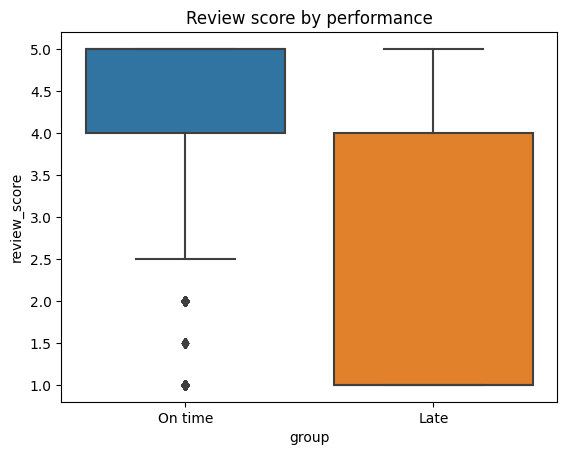

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x="group" ,y="review_score", data= df_ab)
plt.title("Review score by performance")
plt.plot()